<a href="https://colab.research.google.com/github/gopika-vit/Projects-AI/blob/projects-in-colab/ANTCOLONY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ANT COLONY OPT ON MNIST dataset.

In [ ]:
import numpy as np
import cv2
import random
from tensorflow.keras.datasets import mnist
from sklearn.cluster import KMeans

# =========================
# 1. LOAD DATASET
# =========================
(x_train, y_train), (_, _) = mnist.load_data()
image = x_train[0]
image = cv2.resize(image, (64, 64))

h, w = image.shape

# =========================
# 2. ACO PARAMETERS
# =========================
num_ants = 30
num_iterations = 30
alpha = 1.0
beta = 2.0
evaporation = 0.1
Q = 1.0

pheromone = np.ones((h, w))

# =========================
# 3. HELPER FUNCTIONS
# =========================
def heuristic(x1, y1, x2, y2):
    return 1.0 / (1.0 + abs(int(image[x1, y1]) - int(image[x2, y2])))

def get_neighbors(x, y):
    neighbors = []
    for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < h and 0 <= ny < w:
            neighbors.append((nx, ny))
    return neighbors

def ant_walk():
    x, y = random.randint(0, h-1), random.randint(0, w-1)
    path = []

    for _ in range(50):
        neighbors = get_neighbors(x, y)

        probs = []
        for nx, ny in neighbors:
            tau = pheromone[nx, ny] ** alpha
            eta = heuristic(x, y, nx, ny) ** beta
            probs.append(tau * eta)

        probs = np.array(probs)
        probs /= probs.sum()

        choice = np.random.choice(len(neighbors), p=probs)
        x, y = neighbors[choice]
        path.append((x, y))

    return path

# =========================
# 4. ACO MAIN LOOP
# =========================
for iteration in range(num_iterations):
    all_paths = []

    for _ in range(num_ants):
        all_paths.append(ant_walk())

    pheromone *= (1 - evaporation)

    for path in all_paths:
        for (x, y) in path:
            pheromone[x, y] += Q

    print(f"Iteration {iteration+1} done")

# Normalize pheromone
pheromone_img = cv2.normalize(pheromone, None, 0, 255, cv2.NORM_MINMAX)
pheromone_img = pheromone_img.astype(np.uint8)



# =========================
#  EDGE DETECTION (Canny)
# =========================
canny_edges = cv2.Canny(image, 100, 200)

# =========================
#  FEATURE EXTRACTION
# =========================
# Simple features
mean_intensity = np.mean(pheromone_img)
std_intensity = np.std(pheromone_img)
edge_density = np.sum(canny_edges > 0) / (h * w)

features = np.array([mean_intensity, std_intensity, edge_density])
print("Extracted Features:", features)

# =========================
# 8. ACO-BASED CLUSTERING
# =========================
# Use pheromone values as features for clustering
pixels = pheromone_img.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=0).fit(pixels)
clustered = kmeans.labels_.reshape(h, w).astype(np.uint8) * 255

# =========================
# 9. SAVE OUTPUTS
# =========================
cv2.imwrite("original.jpg", image)
cv2.imwrite("canny_edges.jpg", canny_edges)
cv2.imwrite("clustered.jpg", clustered)

print("All outputs saved!")

Iteration 1 done
Iteration 2 done
Iteration 3 done
Iteration 4 done
Iteration 5 done
Iteration 6 done
Iteration 7 done
Iteration 8 done
Iteration 9 done
Iteration 10 done
Iteration 11 done
Iteration 12 done
Iteration 13 done
Iteration 14 done
Iteration 15 done
Iteration 16 done
Iteration 17 done
Iteration 18 done
Iteration 19 done
Iteration 20 done
Iteration 21 done
Iteration 22 done
Iteration 23 done
Iteration 24 done
Iteration 25 done
Iteration 26 done
Iteration 27 done
Iteration 28 done
Iteration 29 done
Iteration 30 done
Extracted Features: [ 7.40307617 19.45496051  0.06176758]
All outputs saved!


Iteration 1: Best Accuracy = 0.8175
Iteration 2: Best Accuracy = 0.8325
Iteration 3: Best Accuracy = 0.8325
Iteration 4: Best Accuracy = 0.8325
Iteration 5: Best Accuracy = 0.8325
Iteration 6: Best Accuracy = 0.8325
Iteration 7: Best Accuracy = 0.8325
Iteration 8: Best Accuracy = 0.8325
Iteration 9: Best Accuracy = 0.8325
Iteration 10: Best Accuracy = 0.8325

Final Accuracy: 0.8325
Selected Features: 99


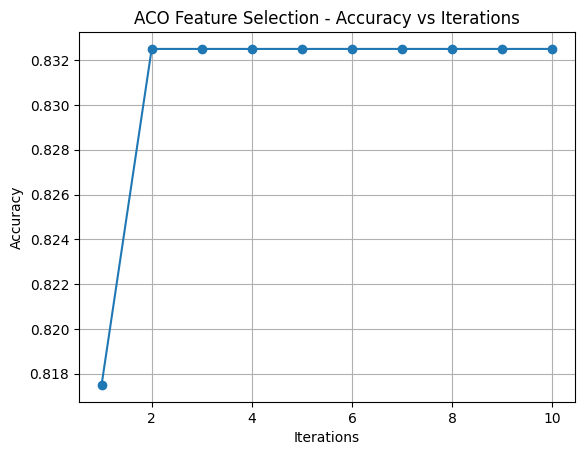

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -----------------------
# Load & preprocess data
# -----------------------
mnist = fetch_openml('mnist_784', version=1, as_frame=True)

X = mnist.data.to_numpy() / 255.0
y = mnist.target.astype(int).to_numpy()

# Reduce dataset size for speed
X, _, y, _ = train_test_split(
    X, y, train_size=4000, stratify=y, random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
accuracy_list = []

# -----------------------
# ACO Parameters
# -----------------------
n_ants = 10
n_iterations = 10
n_features = X.shape[1]

pheromone = np.ones(n_features)
evaporation = 0.3

# -----------------------
# Fitness function
# -----------------------
def evaluate(features):
    if len(features) == 0:
        return 0

    model = LogisticRegression(max_iter=300)

    try:
        model.fit(X_train[:, features], y_train)
        preds = model.predict(X_test[:, features])
        return accuracy_score(y_test, preds)
    except:
        return 0  # handles numerical issues

# -----------------------
# ACO Algorithm
# -----------------------
best_score = 0
best_features = None

for iteration in range(n_iterations):
    solutions = []
    scores = []

    for ant in range(n_ants):
        # Probability distribution from pheromone
        probs = pheromone / pheromone.sum()

        # Select subset size
        size = np.random.randint(40, 100)

        selected = np.random.choice(
            n_features,
            size=size,
            replace=False,
            p=probs
        )

        score = evaluate(selected)

        solutions.append(selected)
        scores.append(score)

        # Track best solution
        if score > best_score:
            best_score = score
            best_features = selected

    # -----------------------
    # Update pheromones
    # -----------------------
    pheromone *= (1 - evaporation)

    for sol, score in zip(solutions, scores):
        pheromone[sol] += score

    print(f"Iteration {iteration+1}: Best Accuracy = {best_score:.4f}")
    accuracy_list.append(best_score)
# -----------------------
# Final Output
# -----------------------
print("\nFinal Accuracy:", best_score)
print("Selected Features:", len(best_features))
import matplotlib.pyplot as plt

iterations = list(range(1, len(accuracy_list) + 1))

plt.figure()
plt.plot(iterations, accuracy_list, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("ACO Feature Selection - Accuracy vs Iterations")
plt.grid()

plt.show()